In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input,GlobalAveragePooling2D, Dense,Dropout,BatchNormalization
from tensorflow.keras.models import Model
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import EarlyStopping

img_height,img_width=224,224
num_class=8
num_folds=5

batch_size=32

2025-06-27 05:20:22.535185: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751001623.034106      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751001623.151929      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import numpy as np
import tensorflow as tf

# Define parameters
img_height, img_width = 224, 224  # Set your desired image height and width
batch_size = 32  # Set your desired batch size

# Load training dataset with the correct image size
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/kaggle/input/3splitdataset/Kvasir3SplitOriginal/Train',
    image_size=(img_height, img_width),  # Ensure images are resized to 224x224
    batch_size=batch_size
)

# Load testing dataset with the correct image size
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/kaggle/input/3splitdataset/Kvasir3SplitOriginal/test',
    image_size=(img_height, img_width),  # Ensure images are resized to 224x224
    batch_size=batch_size
)

# Extracting x_train, y_train
x_train = []
y_train = []
for images, labels in train_dataset:
    x_train.extend(images.numpy())
    y_train.extend(labels.numpy())

# Extracting x_test, y_test
x_test = []
y_test = []
for images, labels in test_dataset:
    x_test.extend(images.numpy())
    y_test.extend(labels.numpy())

# Convert lists to numpy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

Found 5600 files belonging to 8 classes.


I0000 00:00:1751001645.881712      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1751001645.882451      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1600 files belonging to 8 classes.
x_train shape: (5600, 224, 224, 3), y_train shape: (5600,)
x_test shape: (1600, 224, 224, 3), y_test shape: (1600,)


In [3]:
num_classes=8

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters
img_height, img_width = 224, 224
num_classes = 8
epochs = 35
batch_size = 32

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    channel_shift_range=30.0,
    fill_mode='nearest',
)

# Define the base model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Input layer
input_layer = Input(shape=(img_height, img_width, 3))

# Feature extraction and classification head
x = base_model(input_layer, training=False)

# ✅ Add Conv2D layer after base model
x = Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same')(x)

# Continue as before
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.4)(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
output_layer = Dense(num_classes, activation='softmax')(x)

# Create and compile the model
model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train the model
history = model.fit(datagen.flow(x_train, y_train, batch_size=batch_size),
          validation_data=(x_test, y_test),
          epochs=epochs,
          callbacks=[early_stopping, reduce_lr],
          verbose=1)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/35


I0000 00:00:1751001729.309161     103 service.cc:148] XLA service 0x7b4214014d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751001729.310585     103 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1751001729.310604     103 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1751001734.562052     103 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1751001746.622573     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1751001746.765579     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1751001747.214676     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. Th

175/175 ━━━━━━━━━━━━━━━━━━━━ 174s 450ms/step - accuracy: 0.3815 - loss: 1.7378 - val_accuracy: 0.7575 - val_loss: 0.7274 - learning_rate: 1.0000e-04
Epoch 2/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 69s 394ms/step - accuracy: 0.8117 - loss: 0.5181 - val_accuracy: 0.8487 - val_loss: 0.3869 - learning_rate: 1.0000e-04
Epoch 3/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 69s 392ms/step - accuracy: 0.8535 - loss: 0.3895 - val_accuracy: 0.8506 - val_loss: 0.3838 - learning_rate: 1.0000e-04
Epoch 4/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 68s 385ms/step - accuracy: 0.8742 - loss: 0.3445 - val_accuracy: 0.8737 - val_loss: 0.3482 - learning_rate: 1.0000e-04
Epoch 5/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 69s 393ms/step - accuracy: 0.8995 - loss: 0.2671 - val_accuracy: 0.8838 - val_loss: 0.3175 - learning_rate: 1.0000e-04
Epoch 6/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 69s 392ms/step - accuracy: 0.9029 - loss: 0.2557 - val_accuracy: 0.8700 - val_loss: 0.3667 - learning_rate: 1.0000e-04
Epoch 7/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 68s 391ms/step -

In [5]:
# Evaluate accuracy on the validation set
val_loss, val_acc = model.evaluate(x_test, y_test, verbose=0)

# Predict and calculate precision, recall, f1
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)


# Classification report
print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=[f'Class {i}' for i in range(num_classes)]))

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step
📊 Classification Report:
              precision    recall  f1-score   support

     Class 0       0.87      0.89      0.88       200
     Class 1       0.94      0.87      0.90       200
     Class 2       0.86      0.75      0.80       200
     Class 3       0.96      0.98      0.97       200
     Class 4       0.94      1.00      0.97       200
     Class 5       0.79      0.87      0.83       200
     Class 6       0.94      0.93      0.94       200
     Class 7       0.95      0.95      0.95       200

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



In [6]:
model.save('/kaggle/working/EffinetB0Smallnewd.h5')

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

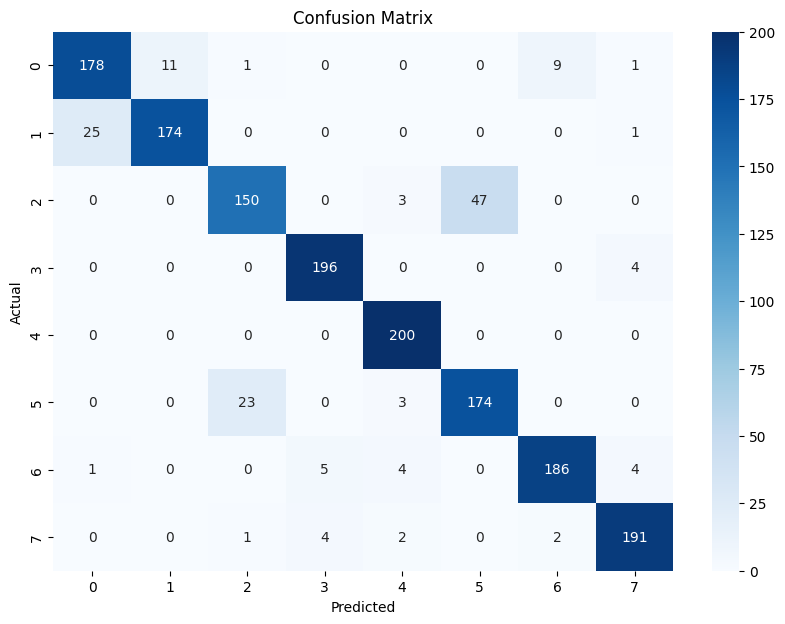

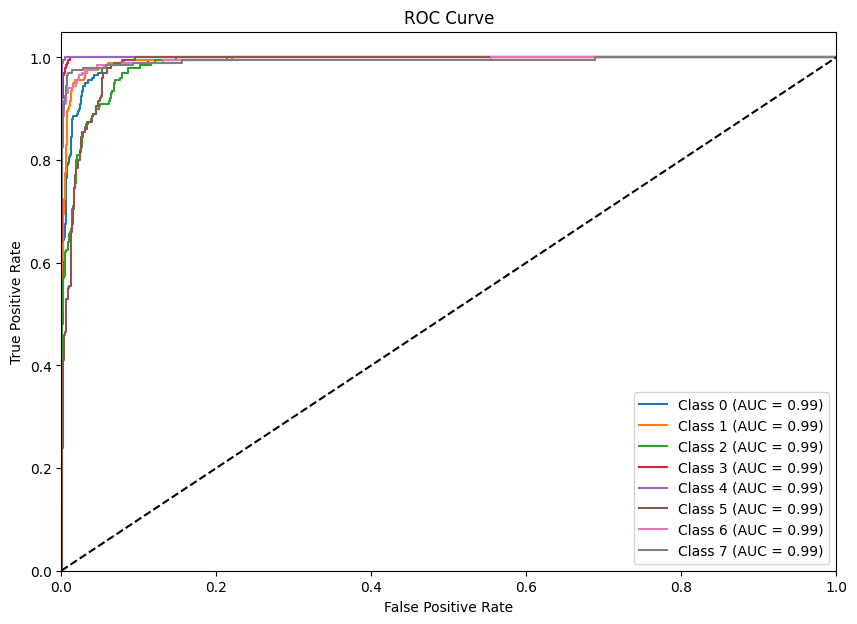

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# AUC-ROC Curve
# Calculate ROC AUC for each class
y_val_one_hot = tf.keras.utils.to_categorical(y_test, num_classes)
roc_auc = roc_auc_score(y_val_one_hot, y_pred_probs, multi_class='ovr')

# Calculate ROC curve
fpr = {}
tpr = {}
thresholds = np.arange(0, 1, 0.01)

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_one_hot[:, i], y_pred_probs[:, i])

# Plot ROC curve
plt.figure(figsize=(10, 7))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


NameError: name 'history' is not defined

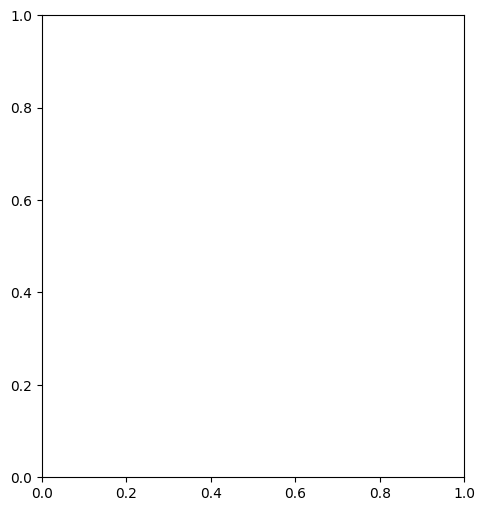

In [9]:
import matplotlib.pyplot as plt

# Plotting the loss curves
plt.figure(figsize=(12, 6))

# Training loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting the accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters
img_height, img_width = 224, 224
num_classes = 8
epochs = 35
batch_size = 32

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    channel_shift_range=30.0,
    fill_mode='nearest',
)

# Define the base model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Input layer
input_layer = Input(shape=(img_height, img_width, 3))

# Feature extraction and classification head
x = base_model(input_layer, training=False)

# ✅ Add Conv2D layer after base model
x = Conv2D(1024, kernel_size=(3, 3), activation='relu', padding='same')(x)

# Continue as before
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.4)(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
output_layer = Dense(num_classes, activation='softmax')(x)

# Create and compile the model
model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train the model
history = model.fit(datagen.flow(x_train, y_train, batch_size=batch_size),
          validation_data=(x_test, y_test),
          epochs=epochs,
          callbacks=[early_stopping, reduce_lr],
          verbose=1)


Epoch 1/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 164s 443ms/step - accuracy: 0.4568 - loss: 1.5137 - val_accuracy: 0.7650 - val_loss: 0.5956 - learning_rate: 1.0000e-04
Epoch 2/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 69s 395ms/step - accuracy: 0.8202 - loss: 0.4800 - val_accuracy: 0.8694 - val_loss: 0.3444 - learning_rate: 1.0000e-04
Epoch 3/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 69s 396ms/step - accuracy: 0.8561 - loss: 0.3617 - val_accuracy: 0.8775 - val_loss: 0.3597 - learning_rate: 1.0000e-04
Epoch 4/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 69s 396ms/step - accuracy: 0.8727 - loss: 0.3248 - val_accuracy: 0.8938 - val_loss: 0.2748 - learning_rate: 1.0000e-04
Epoch 5/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 69s 396ms/step - accuracy: 0.8972 - loss: 0.2957 - val_accuracy: 0.9044 - val_loss: 0.2582 - learning_rate: 1.0000e-04
Epoch 6/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 69s 394ms/step - accuracy: 0.9075 - loss: 0.2422 - val_accuracy: 0.8938 - val_loss: 0.3126 - learning_rate: 1.0000e-04
Epoch 7/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 69s 3

In [12]:
# Evaluate accuracy on the validation set
val_loss, val_acc = model.evaluate(x_test, y_test, verbose=0)

# Predict and calculate precision, recall, f1
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)


# Classification report
print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=[f'Class {i}' for i in range(num_classes)]))

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step
📊 Classification Report:
              precision    recall  f1-score   support

     Class 0       0.90      0.90      0.90       200
     Class 1       0.94      0.90      0.92       200
     Class 2       0.87      0.83      0.85       200
     Class 3       0.96      0.98      0.97       200
     Class 4       0.91      1.00      0.95       200
     Class 5       0.84      0.84      0.84       200
     Class 6       0.94      0.95      0.94       200
     Class 7       0.97      0.92      0.95       200

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



In [13]:
model.save('/kaggle/working/EffinetB0Smallnewd2.h5')

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

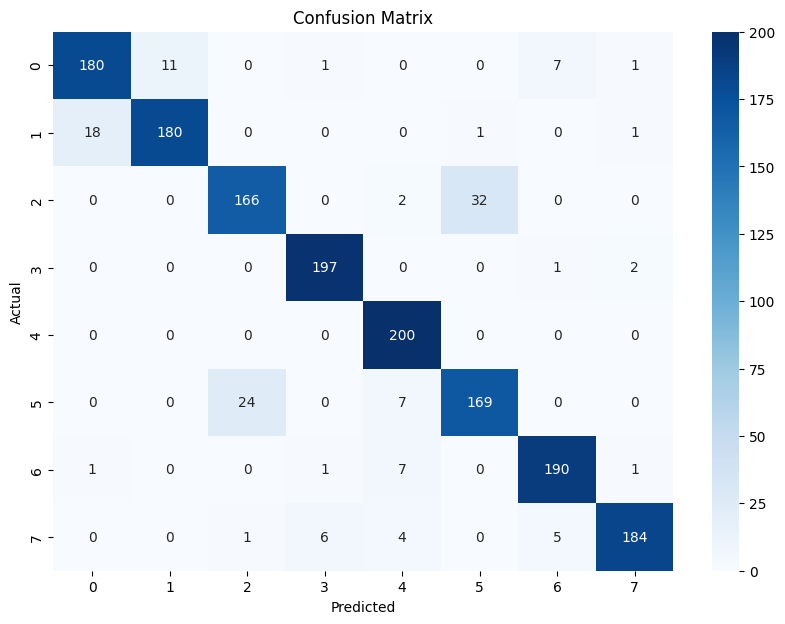

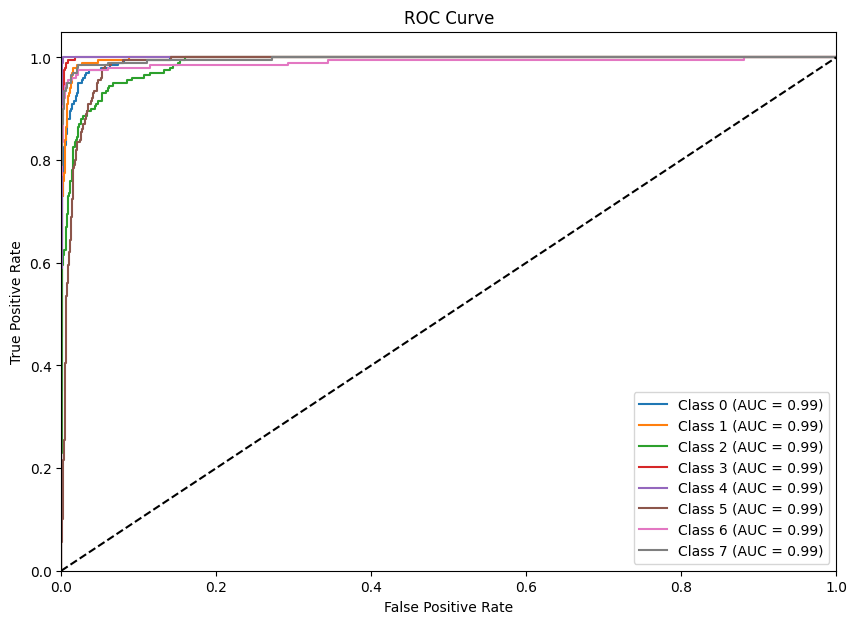

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# AUC-ROC Curve
# Calculate ROC AUC for each class
y_val_one_hot = tf.keras.utils.to_categorical(y_test, num_classes)
roc_auc = roc_auc_score(y_val_one_hot, y_pred_probs, multi_class='ovr')

# Calculate ROC curve
fpr = {}
tpr = {}
thresholds = np.arange(0, 1, 0.01)

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_one_hot[:, i], y_pred_probs[:, i])

# Plot ROC curve
plt.figure(figsize=(10, 7))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


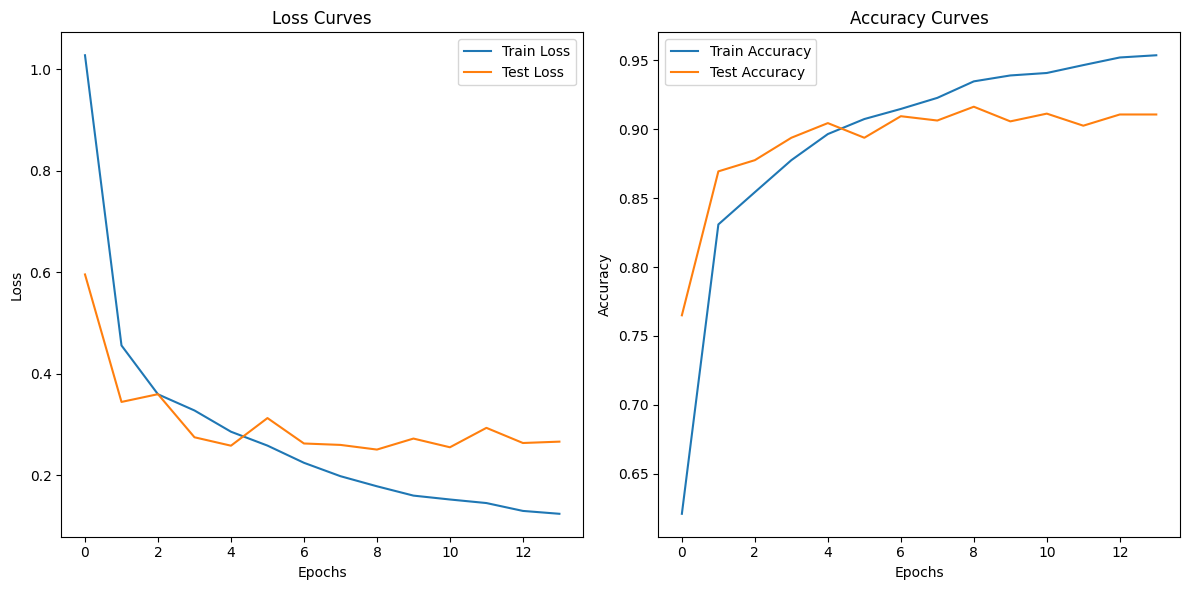

In [17]:
import matplotlib.pyplot as plt

# Plotting the loss curves
plt.figure(figsize=(12, 6))

# Training loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting the accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters
img_height, img_width = 224, 224
num_classes = 8
epochs = 35
batch_size = 32

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    channel_shift_range=30.0,
    fill_mode='nearest',
)

# Define the base model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Input layer
input_layer = Input(shape=(img_height, img_width, 3))

# Feature extraction and classification head
x = base_model(input_layer, training=False)

# ✅ Add Conv2D layer after base model
x = Conv2D(1024, kernel_size=(3, 3), activation='relu', padding='same')(x)

# Continue as before
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.4)(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
output_layer = Dense(num_classes, activation='softmax')(x)

# Create and compile the model
model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train the model
history = model.fit(datagen.flow(x_train, y_train, batch_size=batch_size),
          validation_data=(x_test, y_test),
          epochs=epochs,
          callbacks=[early_stopping, reduce_lr],
          verbose=1)


Epoch 1/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 163s 445ms/step - accuracy: 0.1938 - loss: 2.3659 - val_accuracy: 0.5400 - val_loss: 1.6387 - learning_rate: 1.0000e-05
Epoch 2/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 70s 401ms/step - accuracy: 0.4189 - loss: 1.5407 - val_accuracy: 0.6712 - val_loss: 1.0615 - learning_rate: 1.0000e-05
Epoch 3/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 70s 400ms/step - accuracy: 0.5789 - loss: 1.0878 - val_accuracy: 0.7281 - val_loss: 0.7803 - learning_rate: 1.0000e-05
Epoch 4/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 71s 406ms/step - accuracy: 0.6701 - loss: 0.8710 - val_accuracy: 0.7644 - val_loss: 0.6602 - learning_rate: 1.0000e-05
Epoch 5/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 69s 395ms/step - accuracy: 0.7169 - loss: 0.7304 - val_accuracy: 0.7969 - val_loss: 0.5805 - learning_rate: 1.0000e-05
Epoch 6/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 70s 397ms/step - accuracy: 0.7488 - loss: 0.6466 - val_accuracy: 0.8069 - val_loss: 0.5421 - learning_rate: 1.0000e-05
Epoch 7/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 70s 3

In [28]:
# Evaluate accuracy on the validation set
val_loss, val_acc = model.evaluate(x_test, y_test, verbose=0)

# Predict and calculate precision, recall, f1
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)


# Classification report
print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=[f'Class {i}' for i in range(num_classes)]))

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step
📊 Classification Report:
              precision    recall  f1-score   support

     Class 0       0.89      0.83      0.86       200
     Class 1       0.93      0.89      0.91       200
     Class 2       0.92      0.54      0.68       200
     Class 3       0.96      0.96      0.96       200
     Class 4       0.88      1.00      0.94       200
     Class 5       0.70      0.94      0.80       200
     Class 6       0.86      0.94      0.90       200
     Class 7       0.95      0.91      0.93       200

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.87      1600
weighted avg       0.89      0.88      0.87      1600



In [29]:
model.save('/kaggle/working/EffinetB0Smallnewd3.h5')

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

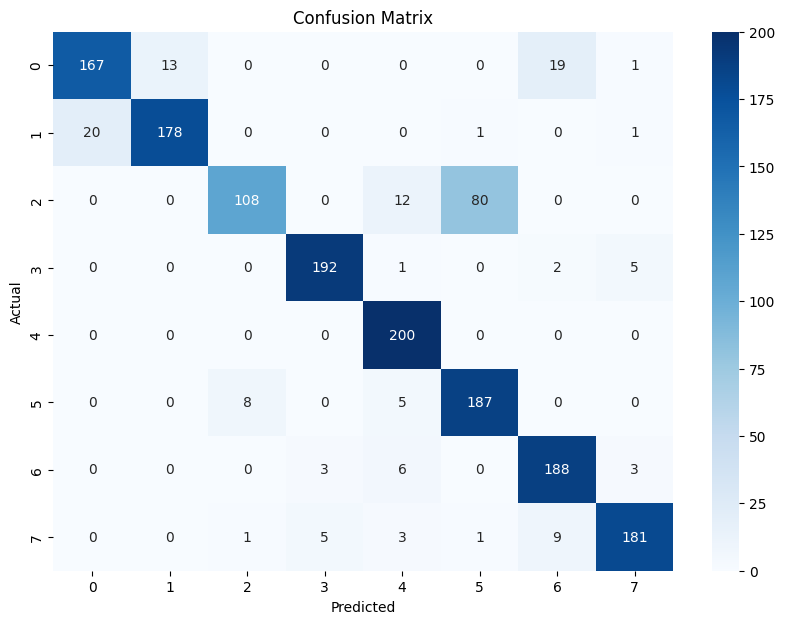

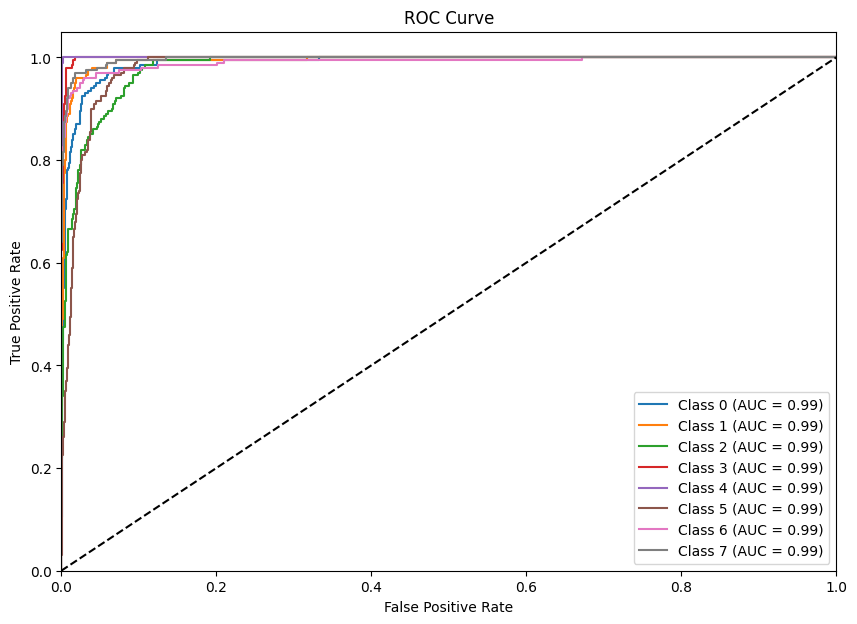

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# AUC-ROC Curve
# Calculate ROC AUC for each class
y_val_one_hot = tf.keras.utils.to_categorical(y_test, num_classes)
roc_auc = roc_auc_score(y_val_one_hot, y_pred_probs, multi_class='ovr')

# Calculate ROC curve
fpr = {}
tpr = {}
thresholds = np.arange(0, 1, 0.01)

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_one_hot[:, i], y_pred_probs[:, i])

# Plot ROC curve
plt.figure(figsize=(10, 7))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

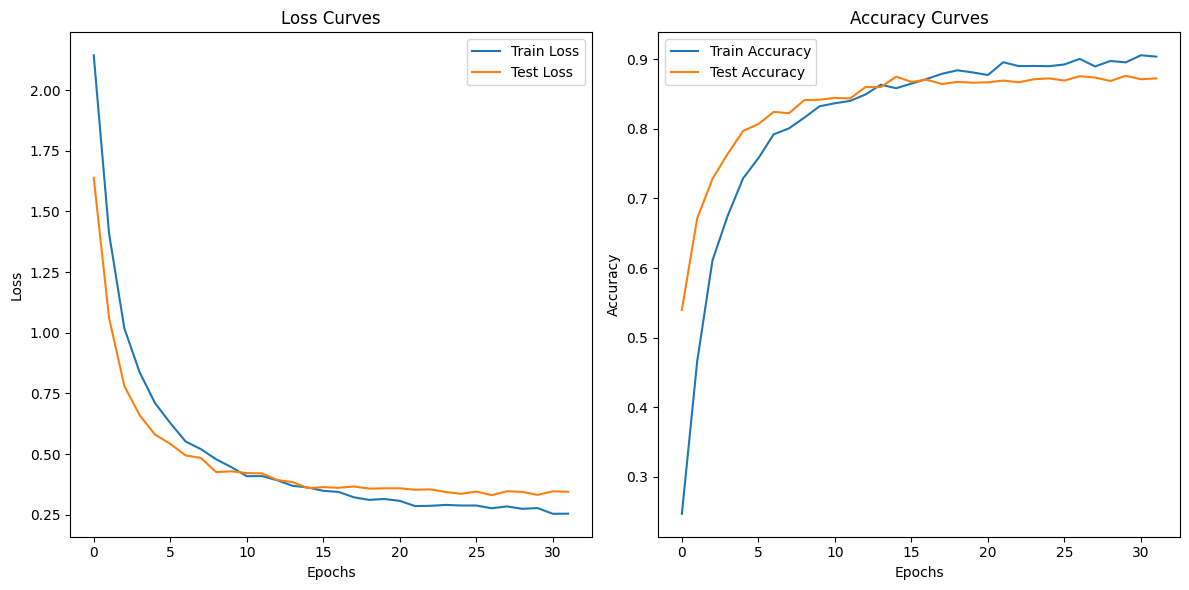

In [34]:
import matplotlib.pyplot as plt

# Plotting the loss curves
plt.figure(figsize=(12, 6))

# Training loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting the accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet152V2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters
img_height, img_width = 224, 224
num_classes = 8
epochs = 35
batch_size = 32

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    channel_shift_range=30.0,
    fill_mode='nearest',
)

# Define the base model
base_model = ResNet152V2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Input layer
input_layer = Input(shape=(img_height, img_width, 3))

# Feature extraction and classification head
x = base_model(input_layer, training=False)

# ✅ Add Conv2D layer after base model
x = Conv2D(1024, kernel_size=(3, 3), activation='relu', padding='same')(x)

# Continue as before
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.4)(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
output_layer = Dense(num_classes, activation='softmax')(x)

# Create and compile the model
model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train the model
history = model.fit(datagen.flow(x_train, y_train, batch_size=batch_size),
          validation_data=(x_test, y_test),
          epochs=epochs,
          callbacks=[early_stopping, reduce_lr],
          verbose=1)


Epoch 1/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 317s 837ms/step - accuracy: 0.4868 - loss: 1.4288 - val_accuracy: 0.8350 - val_loss: 0.4725 - learning_rate: 1.0000e-04
Epoch 2/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 130s 742ms/step - accuracy: 0.8359 - loss: 0.4556 - val_accuracy: 0.8462 - val_loss: 0.4205 - learning_rate: 1.0000e-04
Epoch 3/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 129s 737ms/step - accuracy: 0.8751 - loss: 0.3543 - val_accuracy: 0.8756 - val_loss: 0.3718 - learning_rate: 1.0000e-04
Epoch 4/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 129s 735ms/step - accuracy: 0.8880 - loss: 0.3073 - val_accuracy: 0.8406 - val_loss: 0.4174 - learning_rate: 1.0000e-04
Epoch 5/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 129s 736ms/step - accuracy: 0.8928 - loss: 0.2939 - val_accuracy: 0.8537 - val_loss: 0.4667 - learning_rate: 1.0000e-04
Epoch 6/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 130s 738ms/step - accuracy: 0.9016 - loss: 0.2814 - val_accuracy: 0.8700 - val_loss: 0.3541 - learning_rate: 1.0000e-04
Epoch 7/35
175/175 ━━━━━━━━━━━━━━━━━━━━ 

In [20]:
# Evaluate accuracy on the validation set
val_loss, val_acc = model.evaluate(x_test, y_test, verbose=0)

# Predict and calculate precision, recall, f1
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)


# Classification report
print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=[f'Class {i}' for i in range(num_classes)]))

50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 194ms/step
📊 Classification Report:
              precision    recall  f1-score   support

     Class 0       0.95      0.85      0.90       200
     Class 1       0.93      0.95      0.94       200
     Class 2       0.82      0.79      0.80       200
     Class 3       0.94      1.00      0.97       200
     Class 4       0.95      0.99      0.97       200
     Class 5       0.83      0.83      0.83       200
     Class 6       0.93      0.93      0.93       200
     Class 7       0.97      0.96      0.97       200

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



In [21]:
model.save('/kaggle/working/Resnet152Smallnewd2.h5')

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

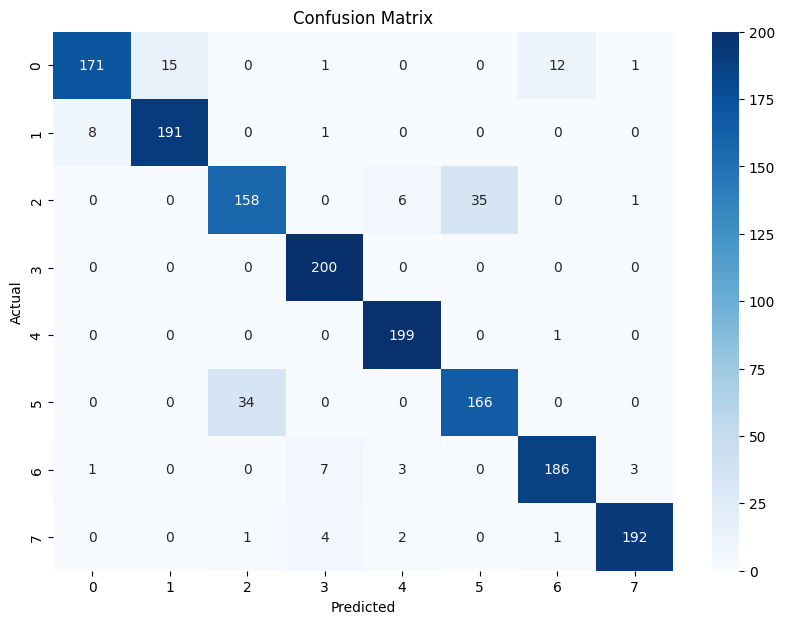

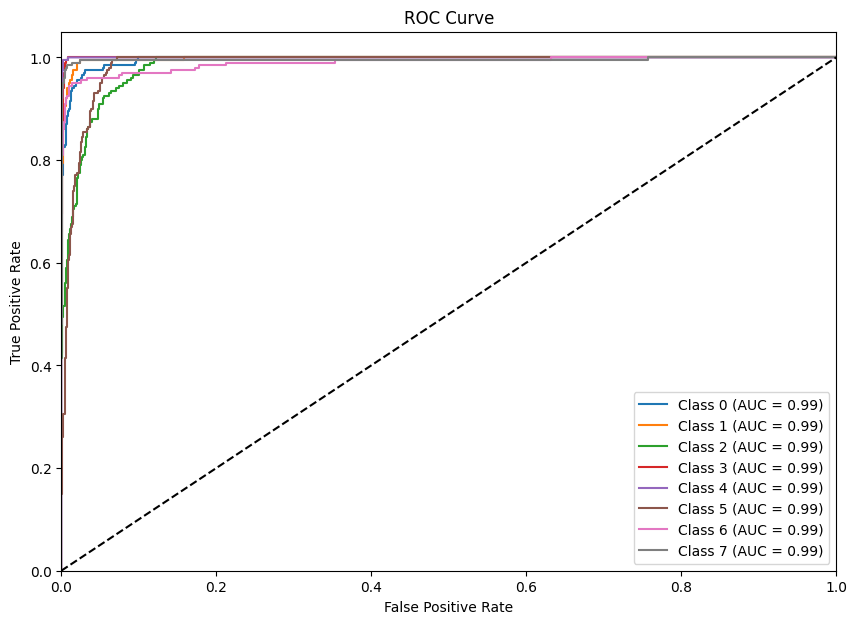

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# AUC-ROC Curve
# Calculate ROC AUC for each class
y_val_one_hot = tf.keras.utils.to_categorical(y_test, num_classes)
roc_auc = roc_auc_score(y_val_one_hot, y_pred_probs, multi_class='ovr')

# Calculate ROC curve
fpr = {}
tpr = {}
thresholds = np.arange(0, 1, 0.01)

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_one_hot[:, i], y_pred_probs[:, i])

# Plot ROC curve
plt.figure(figsize=(10, 7))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

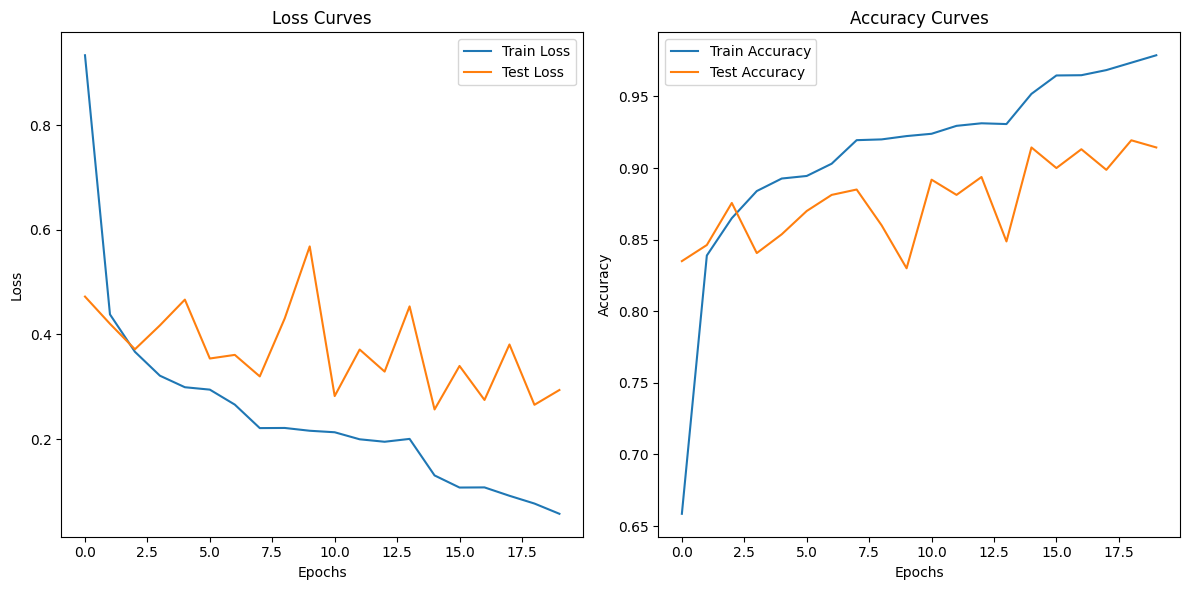

In [24]:
import matplotlib.pyplot as plt

# Plotting the loss curves
plt.figure(figsize=(12, 6))

# Training loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting the accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()